# Phase 1: immutable-log metric repair

**Post-outcome exploratory reanalysis.** Original declared primary: recall@1000. Revised primary: recall@R, selected after outcomes were observed on 2026-09-07. The original metric stays visible beside every metric-summary family. No experiment or loader is invoked. This notebook does not certify recall, establish novelty, or complete external ground-truth verification.

Run all cells from the project root or its notebooks directory. All generated outputs are written to phase1_outputs/, outside the protected results/ tree. A failure is a stop condition; do not change assertions or tolerances to bypass it.

In [1]:
import base64, csv, hashlib, html, importlib.metadata, json, platform, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import HTML, Image, display

ROOT = Path.cwd()
if not (ROOT / "analysis/phase1.py").is_file():
    ROOT = ROOT.parent
if not (ROOT / "analysis/phase1.py").is_file():
    raise RuntimeError("Run from the project root or its notebooks directory.")
sys.path.insert(0, str(ROOT))
from analysis.phase1 import (validate_inputs, run_metrics, topic_metrics,
                            method_metrics, paired_statistics, gain_curves,
                            summary_display, metric_display, OBSERVED, CENSORED)
from analysis.artifact_io import atomic_file
OUT = Path(globals().get("PHASE1_OUTPUT_DIR", ROOT / "phase1_outputs"))
OUT.mkdir(parents=True, exist_ok=True)
hashes = json.loads((ROOT / "phase1_outputs/input_fingerprints.json").read_text())
renames = json.loads((ROOT / "phase1_outputs/authorized_input_renames.json").read_text())

def check_protected():
    changed = [name for name, digest in hashes.items()
               if not (ROOT/renames.get(name, name)).is_file()
               or hashlib.sha256((ROOT/renames.get(name, name)).read_bytes()).hexdigest() != digest]
    if changed:
        raise RuntimeError("Protected inputs changed: " + repr(changed))
    return len(hashes)

print("Protected input hashes verified:", check_protected())
original_plan = json.loads((ROOT / "experiment_plan.json").read_text())
plan = json.loads((ROOT / "experiment_plan_v2.json").read_text())
if original_plan["primary_metric"] != plan["revision"]["original_primary_metric"]:
    raise RuntimeError("Original primary metric does not agree with revision provenance.")
with (ROOT / "results/runs.csv").open(newline="") as handle:
    csv_rows = list(csv.DictReader(handle))
audits = {p.name: json.loads(p.read_text())
          for p in sorted((ROOT / "results/audits").glob("*.json"))}
records = validate_inputs(csv_rows, audits, original_plan)
methods = original_plan["policies"]
topics_order = original_plan["topics"]
FIG = OUT / "figures"
FIG.mkdir(exist_ok=True)
sections = []
print("Validated", len(records), "runs and", len(audits), "audit files.")
print("No load_collection() or experiment.py invocation.")

Protected input hashes verified: 129
Validated 105 runs and 105 audit files.
No load_collection() or experiment.py invocation.


## Definitions and reporting conventions

N and R are taken only from runs.csv. G(k) sums recorded labels through review position k; Rec(k)=G(k)/R. Recall@aR+b uses min(N,aR+b). Target effort is the first position reaching ceil(tR), and whole-batch effort is the first recorded boundary at or after it. Censored effort remains missing, never replaced with the budget. For every incomplete recall mean, the excluded topics and coverage are shown; incomplete effort means are withheld entirely.

The seed is counted once and treated as known. The original plan already disclosed that discovery/search cost was excluded. The benchmark does not independently validate that assumption.

In [2]:
def export_csv(frame, filename, missing_columns=()):
    shown = frame.copy()
    for col in missing_columns:
        if col in shown:
            shown[col] = shown[col].astype(object).where(shown[col].notna(), CENSORED)
    with atomic_file(OUT/filename, "w") as handle:
        shown.to_csv(handle, index=False)

def show_table(title, frame, note=""):
    table_html = frame.to_html(index=False, escape=True, na_rep="NOT COMPUTED",
                              float_format=lambda x: f"{x:.6g}", border=0)
    block = f"<section><h2>{html.escape(title)}</h2><p>{html.escape(note)}</p><div class='table-wrap'>{table_html}</div></section>"
    sections.append(block)
    display(HTML(block))

population = pd.DataFrame([{"topic": q, "N": next(r["n"] for r in records if r["topic"]==q),
                            "R": next(r["positives"] for r in records if r["topic"]==q)}
                           for q in topics_order])
population["prevalence"] = population.R / population.N
population["recall_at_1000_ceiling"] = np.minimum(1000/population.R, 1)
metrics = run_metrics(records)
topic_values = topic_metrics(metrics)
summary = method_metrics(topic_values)
stats, differences = paired_statistics(
    topic_values, methods,
    bootstrap_resamples=plan["analysis"]["bootstrap_resamples"],
    analysis_seed=plan["analysis"]["analysis_seed"])
curves = gain_curves(records)
export_csv(population, "population.csv")
export_csv(metrics, "metrics_by_run.csv", ("value",))
export_csv(topic_values, "metrics_by_topic.csv", ("value",))
export_csv(summary, "metrics_by_method.csv", ("full_mean",))
export_csv(stats, "paired_statistics.csv")
export_csv(differences, "paired_topic_differences.csv", ("difference",))
curves.to_csv(OUT/"gain_curves.csv.gz", index=False, compression={"method":"gzip", "mtime":0})
show_table("Collection counts and original recall@1000 ceilings", population,
           "Counts come exclusively from runs.csv. The original metric's ceiling varies by topic.")
print("Metric rows:", len(metrics), "| Topic rows:", len(topic_values),
      "| Pairwise contrasts:", len(stats), "| Full observed gain positions:", len(curves))

Metric rows: 2520 | Topic rows: 840 | Pairwise contrasts: 504 | Full observed gain positions: 525000


topic,N,R,prevalence,recall_at_1000_ceiling
C12,23149,381,0.0164586,1
C15,23149,4179,0.180526,0.239292
C16,23149,49,0.00211672,1
C18,23149,1462,0.0631561,0.683995
GCRIM,23149,1133,0.0489438,0.882613


In [3]:
primary_names = ["recall_at_R", "recall_at_1000", "recall_at_2R"]
primary_display = summary_display(summary, primary_names, methods)
export_csv(primary_display, "primary_metrics_display.csv")
show_table("Reportable core: recall@R is fully observed; original recall@1000 retained", primary_display,
           "Every complete mean covers five topics and all three seeds. Recall@2R partial means explicitly exclude censored topics.")

for a in plan["metric_parameters"]["a"]:
    names = ["recall_at_1000"] + [f"recall_at_{a}R_plus_{b}" for b in plan["metric_parameters"]["b"]]
    tab = summary_display(summary, names, methods)
    export_csv(tab, f"scaled_recall_{a}R_display.csv")
    show_table(f"Scaled recall cutoffs: a={a}", tab,
               "Recall@1000 is repeated as the original declared primary. No cutoff beyond the logged budget is inferred.")

for target in (75, 80, 90):
    names = ["recall_at_1000"] + [f"{stem}_at_{target}" for stem in
                                 ("effort", "batch_effort", "depth_fraction", "depth_per_positive")]
    tab = summary_display(summary, names, methods)
    export_csv(tab, f"target_{target}_display.csv")
    show_table(f"Target {target}%: exact, whole-batch, and normalized depths", tab,
               "Any censored seed prevents its topic mean; any censored topic prevents the full effort mean. No success-only means.")

method,recall_at_R,recall_at_1000,recall_at_2R
random,7.07%,4.68%,CENSORED | PARTIAL 7.38% (4/5; excludes C15)
seed_similarity,26.62%,27.24%,CENSORED | PARTIAL 29.67% (4/5; excludes C15)
frozen_svm,25.76%,27.73%,CENSORED | PARTIAL 32.27% (4/5; excludes C15)
uncertainty,40.67%,51.02%,CENSORED | PARTIAL 58.23% (4/5; excludes C15)
auto_tar,65.27%,66.43%,CENSORED | PARTIAL 73.89% (4/5; excludes C15)
fixed_20,64.64%,66.40%,CENSORED | PARTIAL 74.16% (4/5; excludes C15)
explore_10,63.11%,64.26%,CENSORED | PARTIAL 73.19% (4/5; excludes C15)


method,recall_at_1000,recall_at_1R_plus_0,recall_at_1R_plus_100,recall_at_1R_plus_1000
random,4.68%,7.07%,7.38%,CENSORED | PARTIAL 8.10% (4/5; excludes C15)
seed_similarity,27.24%,26.62%,28.97%,CENSORED | PARTIAL 37.67% (4/5; excludes C15)
frozen_svm,27.73%,25.76%,28.33%,CENSORED | PARTIAL 40.39% (4/5; excludes C15)
uncertainty,51.02%,40.67%,45.03%,CENSORED | PARTIAL 75.17% (4/5; excludes C15)
auto_tar,66.43%,65.27%,69.36%,CENSORED | PARTIAL 91.78% (4/5; excludes C15)
fixed_20,66.40%,64.64%,70.42%,CENSORED | PARTIAL 91.88% (4/5; excludes C15)
explore_10,64.26%,63.11%,67.29%,CENSORED | PARTIAL 90.72% (4/5; excludes C15)


method,recall_at_1000,recall_at_2R_plus_0,recall_at_2R_plus_100,recall_at_2R_plus_1000
random,4.68%,CENSORED | PARTIAL 7.38% (4/5; excludes C15),CENSORED | PARTIAL 7.73% (4/5; excludes C15),CENSORED | PARTIAL 11.00% (4/5; excludes C15)
seed_similarity,27.24%,CENSORED | PARTIAL 29.67% (4/5; excludes C15),CENSORED | PARTIAL 31.48% (4/5; excludes C15),CENSORED | PARTIAL 44.10% (4/5; excludes C15)
frozen_svm,27.73%,CENSORED | PARTIAL 32.27% (4/5; excludes C15),CENSORED | PARTIAL 34.68% (4/5; excludes C15),CENSORED | PARTIAL 46.40% (4/5; excludes C15)
uncertainty,51.02%,CENSORED | PARTIAL 58.23% (4/5; excludes C15),CENSORED | PARTIAL 64.95% (4/5; excludes C15),CENSORED | PARTIAL 79.56% (4/5; excludes C15)
auto_tar,66.43%,CENSORED | PARTIAL 73.89% (4/5; excludes C15),CENSORED | PARTIAL 80.38% (4/5; excludes C15),CENSORED | PARTIAL 93.62% (4/5; excludes C15)
fixed_20,66.40%,CENSORED | PARTIAL 74.16% (4/5; excludes C15),CENSORED | PARTIAL 80.24% (4/5; excludes C15),CENSORED | PARTIAL 93.50% (4/5; excludes C15)
explore_10,64.26%,CENSORED | PARTIAL 73.19% (4/5; excludes C15),CENSORED | PARTIAL 77.33% (4/5; excludes C15),CENSORED | PARTIAL 93.45% (4/5; excludes C15)


method,recall_at_1000,recall_at_4R_plus_0,recall_at_4R_plus_100,recall_at_4R_plus_1000
random,4.68%,"CENSORED | PARTIAL 10.23% (3/5; excludes C15,C18)","CENSORED | PARTIAL 10.90% (3/5; excludes C15,C18)","CENSORED | PARTIAL 7.99% (2/5; excludes C15,C18,GCRIM)"
seed_similarity,27.24%,"CENSORED | PARTIAL 39.77% (3/5; excludes C15,C18)","CENSORED | PARTIAL 42.65% (3/5; excludes C15,C18)","CENSORED | PARTIAL 47.64% (2/5; excludes C15,C18,GCRIM)"
frozen_svm,27.73%,"CENSORED | PARTIAL 43.57% (3/5; excludes C15,C18)","CENSORED | PARTIAL 45.92% (3/5; excludes C15,C18)","CENSORED | PARTIAL 47.40% (2/5; excludes C15,C18,GCRIM)"
uncertainty,51.02%,"CENSORED | PARTIAL 66.38% (3/5; excludes C15,C18)","CENSORED | PARTIAL 75.28% (3/5; excludes C15,C18)","CENSORED | PARTIAL 85.51% (2/5; excludes C15,C18,GCRIM)"
auto_tar,66.43%,"CENSORED | PARTIAL 78.06% (3/5; excludes C15,C18)","CENSORED | PARTIAL 86.88% (3/5; excludes C15,C18)","CENSORED | PARTIAL 91.20% (2/5; excludes C15,C18,GCRIM)"
fixed_20,66.40%,"CENSORED | PARTIAL 77.73% (3/5; excludes C15,C18)","CENSORED | PARTIAL 86.66% (3/5; excludes C15,C18)","CENSORED | PARTIAL 90.86% (2/5; excludes C15,C18,GCRIM)"
explore_10,64.26%,"CENSORED | PARTIAL 74.63% (3/5; excludes C15,C18)","CENSORED | PARTIAL 85.94% (3/5; excludes C15,C18)","CENSORED | PARTIAL 91.11% (2/5; excludes C15,C18,GCRIM)"


method,recall_at_1000,effort_at_75,batch_effort_at_75,depth_fraction_at_75,depth_per_positive_at_75
random,4.68%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
seed_similarity,27.24%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
frozen_svm,27.73%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
uncertainty,51.02%,"CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean"
auto_tar,66.43%,"1,310.533","1,399.933",0.057,1.919
fixed_20,66.40%,"1,290.933","1,302.333",0.056,2.005
explore_10,64.26%,"1,405.133","1,525.400",0.061,2.062


method,recall_at_1000,effort_at_80,batch_effort_at_80,depth_fraction_at_80,depth_per_positive_at_80
random,4.68%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
seed_similarity,27.24%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
frozen_svm,27.73%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
uncertainty,51.02%,"CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean","CENSORED (topics: C15,GCRIM); no mean"
auto_tar,66.43%,"1,468.067","1,565.733",0.063,2.341
fixed_20,66.40%,"1,424.067","1,433.000",0.062,2.249
explore_10,64.26%,"1,552.667","1,660.533",0.067,2.344


method,recall_at_1000,effort_at_90,batch_effort_at_90,depth_fraction_at_90,depth_per_positive_at_90
random,4.68%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
seed_similarity,27.24%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
frozen_svm,27.73%,"CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C16,C18,GCRIM); no mean"
uncertainty,51.02%,"CENSORED (topics: C12,C15,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C18,GCRIM); no mean","CENSORED (topics: C12,C15,C18,GCRIM); no mean"
auto_tar,66.43%,"2,582.667","2,724.267",0.112,15.725
fixed_20,66.40%,"2,519.933","2,530.333",0.109,15.706
explore_10,64.26%,CENSORED (topics: C16); no mean,CENSORED (topics: C16); no mean,CENSORED (topics: C16); no mean,CENSORED (topics: C16); no mean


In [4]:
for q in topics_order:
    selected = topic_values[topic_values.topic.eq(q)]
    rows = []
    for method in methods:
        row = {"method": method}
        for metric in primary_names + ["effort_at_75", "effort_at_80", "effort_at_90", "batch_effort_at_90"]:
            x = selected[(selected.policy==method) & (selected.metric==metric)].iloc[0]
            row[metric] = metric_display(x.value, x.status, metric)
            if x.status != OBSERVED:
                row[metric] += f" (seeds: {x.censored_seeds})"
        rows.append(row)
    tab = pd.DataFrame(rows)
    export_csv(tab, f"topic_{q}_display.csv")
    show_table(f"Topic {q}: original metric, scaled recall and target effort", tab,
               "Means require all three seeds; censored seed IDs remain visible. Full per-seed measures are in metrics_by_run.csv.")

censor_inventory = metrics[metrics.status.eq(CENSORED)][
    ["topic", "seed", "policy", "metric", "reviewed", "requested_depth", "censor_lower_bound", "censor_reason"]].copy()
export_csv(censor_inventory, "censor_inventory.csv")
print("Censored metric entries:", len(censor_inventory),
      "| Detailed topic/seed/method/cutoff inventory exported.")
census_rows = []
for metric in metrics.metric.drop_duplicates():
    missing = metrics[(metrics.metric == metric) & metrics.status.eq(CENSORED)]
    pairs = stats[stats.metric.eq(metric)]
    missing_pairs = pairs[pairs.status.ne(OBSERVED)]
    topic_runs = missing.groupby("topic").size().to_dict()
    topic_pairs = {q: sum(q in str(x).split(",") for x in missing_pairs.censored_topics)
                   for q in topics_order}
    census_rows.append({
        "metric": metric, "censored_runs": len(missing), "total_runs": len(records),
        "censored_policy_pairs": len(missing_pairs), "total_policy_pairs": len(pairs),
        "run_censor_topics": "; ".join(f"{q}:{int(v)}" for q,v in topic_runs.items()),
        "pair_censor_topics": "; ".join(f"{q}:{v}" for q,v in topic_pairs.items() if v)})
census = pd.DataFrame(census_rows)
export_csv(census, "censoring_census.csv")
show_table("Censoring census: runs and full-topic policy comparisons", census,
           "Each metric has 105 runs and 21 policy pairs. A pair is censored if either policy has any censored seed on any topic. Topic counts overlap for pairs and must not be added. Recall@1000 remains visible.")


Censored metric entries: 840 | Detailed topic/seed/method/cutoff inventory exported.


method,recall_at_R,recall_at_1000,recall_at_2R,effort_at_75,effort_at_80,effort_at_90,batch_effort_at_90
random,2.01%,5.25%,3.67%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
seed_similarity,26.95%,42.43%,37.71%,"CENSORED (seeds: 29,47)","CENSORED (seeds: 29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
frozen_svm,28.43%,45.06%,39.55%,CENSORED (seeds: 47),"CENSORED (seeds: 29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
uncertainty,47.42%,74.37%,69.55%,"1,032.333","1,662.000","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
auto_tar,65.44%,89.15%,84.86%,533.000,642.333,"1,071.000","1,148.333"
fixed_20,66.40%,89.50%,86.61%,502.333,578.000,"1,066.000","1,081.000"
explore_10,63.60%,88.45%,83.20%,548.667,655.000,"1,170.667","1,233.000"


method,recall_at_R,recall_at_1000,recall_at_2R,effort_at_75,effort_at_80,effort_at_90,batch_effort_at_90
random,18.08%,4.47%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
seed_similarity,52.22%,18.26%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
frozen_svm,41.29%,15.35%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
uncertainty,39.02%,13.22%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
auto_tar,87.27%,23.75%,"CENSORED (seeds: 11,29,47)","3,301.667","3,589.667","4,486.667","4,698.000"
fixed_20,89.18%,23.67%,"CENSORED (seeds: 11,29,47)","3,225.667","3,482.667","4,285.000","4,301.000"
explore_10,84.99%,22.00%,"CENSORED (seeds: 11,29,47)","3,529.667","3,802.333","4,737.333","4,899.333"


method,recall_at_R,recall_at_1000,recall_at_2R,effort_at_75,effort_at_80,effort_at_90,batch_effort_at_90
random,2.72%,4.08%,2.72%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
seed_similarity,2.72%,31.29%,6.12%,"CENSORED (seeds: 11,29)","CENSORED (seeds: 11,29)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
frozen_svm,3.40%,30.61%,6.12%,"CENSORED (seeds: 11,29)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
uncertainty,18.37%,88.44%,23.13%,269.333,333.000,"3,516.667","3,649.667"
auto_tar,18.37%,88.44%,22.45%,270.667,344.667,"3,516.667","3,649.667"
fixed_20,11.56%,87.76%,21.09%,297.333,333.000,"3,519.667","3,527.667"
explore_10,18.37%,88.44%,22.45%,293.333,333.667,CENSORED (seeds: 47),CENSORED (seeds: 47)


method,recall_at_R,recall_at_1000,recall_at_2R,effort_at_75,effort_at_80,effort_at_90,batch_effort_at_90
random,7.11%,4.83%,12.90%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
seed_similarity,21.48%,16.71%,32.95%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
frozen_svm,23.92%,18.42%,36.32%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
uncertainty,50.16%,35.73%,74.58%,"2,995.667","4,312.000","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
auto_tar,76.79%,57.89%,95.37%,"1,408.333","1,579.667","2,101.667","2,241.333"
fixed_20,76.97%,58.09%,95.53%,"1,394.667","1,562.000","2,076.333","2,081.000"
explore_10,73.12%,53.85%,94.89%,"1,527.667","1,714.000","2,271.333","2,400.333"


method,recall_at_R,recall_at_1000,recall_at_2R,effort_at_75,effort_at_80,effort_at_90,batch_effort_at_90
random,5.41%,4.77%,10.24%,"CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
seed_similarity,29.71%,27.51%,41.89%,"CENSORED (seeds: 29,47)","CENSORED (seeds: 29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
frozen_svm,31.74%,29.19%,47.07%,"CENSORED (seeds: 29,47)","CENSORED (seeds: 29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
uncertainty,48.37%,43.37%,65.67%,"CENSORED (seeds: 11,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)","CENSORED (seeds: 11,29,47)"
auto_tar,78.49%,72.93%,92.88%,"1,039.000","1,184.000","1,737.333","1,884.000"
fixed_20,79.08%,72.99%,93.41%,"1,034.667","1,164.667","1,652.667","1,661.000"
explore_10,75.46%,68.58%,92.20%,"1,126.333","1,258.333","1,881.333","2,021.333"


metric,censored_runs,total_runs,censored_policy_pairs,total_policy_pairs,run_censor_topics,pair_censor_topics
recall_at_1000,0,105,0,21,,
recall_at_R,0,105,0,21,,
recall_at_2R,21,105,21,21,C15:21,C15:21
recall_at_1R_plus_0,0,105,0,21,,
recall_at_1R_plus_100,0,105,0,21,,
recall_at_1R_plus_1000,21,105,21,21,C15:21,C15:21
recall_at_2R_plus_0,21,105,21,21,C15:21,C15:21
recall_at_2R_plus_100,21,105,21,21,C15:21,C15:21
recall_at_2R_plus_1000,21,105,21,21,C15:21,C15:21
recall_at_4R_plus_0,42,105,21,21,C15:21; C18:21,C15:21; C18:21


## Paired topic inference

All comparisons below are exploratory, unadjusted, and selected after original outcomes were available. Differences are method_a minus method_b. Average all seeds within each topic before resampling topics or flipping signs. No test is performed after dropping censored topics. Exact Wilcoxon sign enumeration drops zero pairs and uses average ranks for ties.

With only five topics, bootstrap intervals are unstable. An interval excluding zero does not override an exact test whose attainable p-values cannot reach 0.05. Nonsignificance is not equivalence.

In [5]:
anchor = stats[stats.metric.eq("recall_at_1000")][
    ["method_a", "method_b", "mean_difference", "exact_sign_flip_p"]].rename(
    columns={"mean_difference":"original_recall_at_1000_difference",
             "exact_sign_flip_p":"original_recall_at_1000_sign_flip_p"})
stats_with_anchor = stats.merge(anchor, on=["method_a","method_b"], how="left", validate="many_to_one")
export_csv(stats_with_anchor, "paired_statistics_with_original_metric.csv")
for metric in primary_names + [m for m in stats.metric.unique() if m not in primary_names]:
    s = stats_with_anchor[stats_with_anchor.metric.eq(metric)].copy()
    if metric.startswith("recall_"):
        for col in ("mean_difference", "bootstrap_ci_low", "bootstrap_ci_high",
                    "original_recall_at_1000_difference", "bca_ci_low", "bca_ci_high") + tuple("difference_"+q for q in topics_order):
            s[col+"_pp"] = 100*s[col]
    columns = ["method_a","method_b","status","topics_used","nonzero_pairs",
               "mean_difference_pp","bootstrap_ci_low_pp","bootstrap_ci_high_pp",
               "exact_sign_flip_p","wilcoxon_exact_p","minimum_two_sided_p",
               "original_recall_at_1000_difference_pp","censored_topics","note"]
    units = "_pp" if metric.startswith("recall_") else ""
    columns = ["method_a","method_b","status","topics_used","exact_sign_flip_p"] + [
        "difference_"+q+units for q in topics_order] + [
        "mean_difference"+units, "bootstrap_ci_low"+units, "bootstrap_ci_high"+units,
        "bca_ci_low"+units, "bca_ci_high"+units, "bca_status", "interval_disagreement",
        "minimum_two_sided_p", "censored_topics", "note"]
    show_table(f"Paired topic statistics: {metric}", s[columns],
               "Recall differences/intervals are percentage points; effort uses its named units. Raw five topic differences accompany BOTH percentile (bootstrap_ci) and BCa intervals. Exact sign-flip is primary. Neither interval is reliable with five topics. NOT COMPUTED means full-topic comparison is censored.")

show_table("Statistical coverage across the entire metric suite",
           stats.groupby(["metric","status"], dropna=False).size().rename("contrasts").reset_index(),
           "Original recall@1000 is retained in this inventory. Detailed results for every pair/metric include that original metric as an anchor column in paired_statistics_with_original_metric.csv.")

method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,OBSERVED,5,0.125,-24.9344,-34.1389,0,-14.3639,-24.3013,-19.5477,-28.4896,-8.61833,-28.343,-7.73303,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.125,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.125 exceeds 0.05 for 4 nonzero pairs.
random,frozen_svm,OBSERVED,5,0.0625,-26.4217,-23.2113,-0.680272,-16.8035,-26.3313,-18.6896,-25.7434,-9.03511,-24.4955,-5.81047,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,uncertainty,OBSERVED,5,0.0625,-45.4068,-20.938,-15.6463,-43.0461,-42.9538,-33.5982,-43.9719,-22.1846,-43.9535,-22.1661,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,auto_tar,OBSERVED,5,0.0625,-63.4296,-69.1872,-15.6463,-69.6762,-73.0803,-58.2039,-70.9401,-36.6897,-70.1614,-26.3544,OBSERVED,MATERIAL,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. BCa and percentile disagree materially: interval inference is not trustworthy here. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,fixed_20,OBSERVED,5,0.0625,-64.392,-71.1015,-8.84354,-69.8586,-73.6687,-57.5729,-71.8798,-32.9183,-71.1178,-21.1282,OBSERVED,MATERIAL,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. BCa and percentile disagree materially: interval inference is not trustworthy here. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,explore_10,OBSERVED,5,0.0625,-61.5923,-66.906,-15.6463,-66.0055,-70.05,-56.04,-67.9835,-35.7162,-67.1746,-25.8982,OBSERVED,MATERIAL,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. BCa and percentile disagree materially: interval inference is not trustworthy here. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,frozen_svm,OBSERVED,5,1,-1.48731,10.9277,-0.680272,-2.43958,-2.03001,0.858096,-2.0853,5.96167,-1.89485,8.44466,OBSERVED,MATERIAL,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. BCa and percentile disagree materially: interval inference is not trustworthy here. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,uncertainty,OBSERVED,5,0.125,-20.4724,13.2009,-15.6463,-28.6822,-18.6525,-14.0505,-24.0691,0.459537,-22.7911,4.82431,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,auto_tar,OBSERVED,5,0.0625,-38.4952,-35.0483,-15.6463,-55.3124,-48.7791,-

method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,OBSERVED,5,0.0625,-37.1829,-13.7912,-27.2109,-11.8787,-22.742,-22.5611,-30.5101,-14.8163,-31.4065,-15.3276,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,frozen_svm,OBSERVED,5,0.0625,-39.8075,-10.8878,-26.5306,-13.5887,-24.4189,-23.0467,-31.9084,-14.5565,-34.0744,-15.0967,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,uncertainty,OBSERVED,5,0.0625,-69.1164,-8.7501,-84.3537,-30.8938,-38.5996,-46.3427,-70.6143,-23.5775,-70.6143,-23.5775,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,auto_tar,OBSERVED,5,0.0625,-83.902,-19.2789,-84.3537,-53.0552,-68.1671,-61.7514,-80.9357,-38.9588,-77.9133,-32.7894,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,fixed_20,OBSERVED,5,0.0625,-84.252,-19.2071,-83.6735,-53.2604,-68.2259,-61.7238,-80.8154,-39.0268,-77.8222,-32.8284,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
random,explore_10,OBSERVED,5,0.0625,-83.2021,-17.5321,-84.3537,-49.0196,-63.8129,-59.5841,-79.5546,-36.9636,-77.0566,-33.0858,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,frozen_svm,OBSERVED,5,0.6875,-2.62467,2.90341,0.680272,-1.70999,-1.67696,-0.485589,-2.06926,1.5361,-1.9583,1.56953,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,uncertainty,OBSERVED,5,0.125,-31.9335,5.04108,-57.1429,-19.015,-15.8576,-23.7816,-42.0172,-7.16506,-43.8439,-8.12962,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is not equivalence. Minimum attainable two-sided p=0.0625 exceeds 0.05 for 5 nonzero pairs.
seed_similarity,auto_tar,OBSERVED,5,0.0625,-46.7192,-5.48776,-57.1429,-41.1765,-45.4251,-39.1903,-51.606,-20.8718,-49.7801,-13.734,OBSERVED,BELOW_DIAGNOSTIC_THRESHOLD,0.0625,,Exact sign-flip is primary. Both bootstrap variants are exploratory and unreliable with five topics; agreement does not establish coverage; nonsignificance is no

method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.


method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12,difference_C15,difference_C16,difference_C18,difference_GCRIM,mean_difference,bootstrap_ci_low,bootstrap_ci_high,bca_ci_low,bca_ci_high,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.


method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12,difference_C15,difference_C16,difference_C18,difference_GCRIM,mean_difference,bootstrap_ci_low,bootstrap_ci_high,bca_ci_low,bca_ci_high,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C12,C15,C16,C18,GCRIM",No inference on a complete-case subset; censored topics listed.


...

method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,C15,No inference on a complete-case subset; censored topics listed.


method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.


method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18",No inference on a complete-case subset; censored topics listed.


method_a,method_b,status,topics_used,exact_sign_flip_p,difference_C12_pp,difference_C15_pp,difference_C16_pp,difference_C18_pp,difference_GCRIM_pp,mean_difference_pp,bootstrap_ci_low_pp,bootstrap_ci_high_pp,bca_ci_low_pp,bca_ci_high_pp,bca_status,interval_disagreement,minimum_two_sided_p,censored_topics,note
random,seed_similarity,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
random,explore_10,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,frozen_svm,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,uncertainty,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,auto_tar,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.
seed_similarity,fixed_20,NOT_COMPUTED_CENSORED,0,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,NOT COMPUTED,"C15,C18,GCRIM",No inference on a complete-case subset; censored topics listed.


metric,status,contrasts
batch_effort_at_75,NOT_COMPUTED_CENSORED,18
batch_effort_at_75,OBSERVED,3
batch_effort_at_80,NOT_COMPUTED_CENSORED,18
batch_effort_at_80,OBSERVED,3
batch_effort_at_90,NOT_COMPUTED_CENSORED,20
batch_effort_at_90,OBSERVED,1
depth_fraction_at_75,NOT_COMPUTED_CENSORED,18
depth_fraction_at_75,OBSERVED,3
depth_fraction_at_80,NOT_COMPUTED_CENSORED,18
depth_fraction_at_80,OBSERVED,3


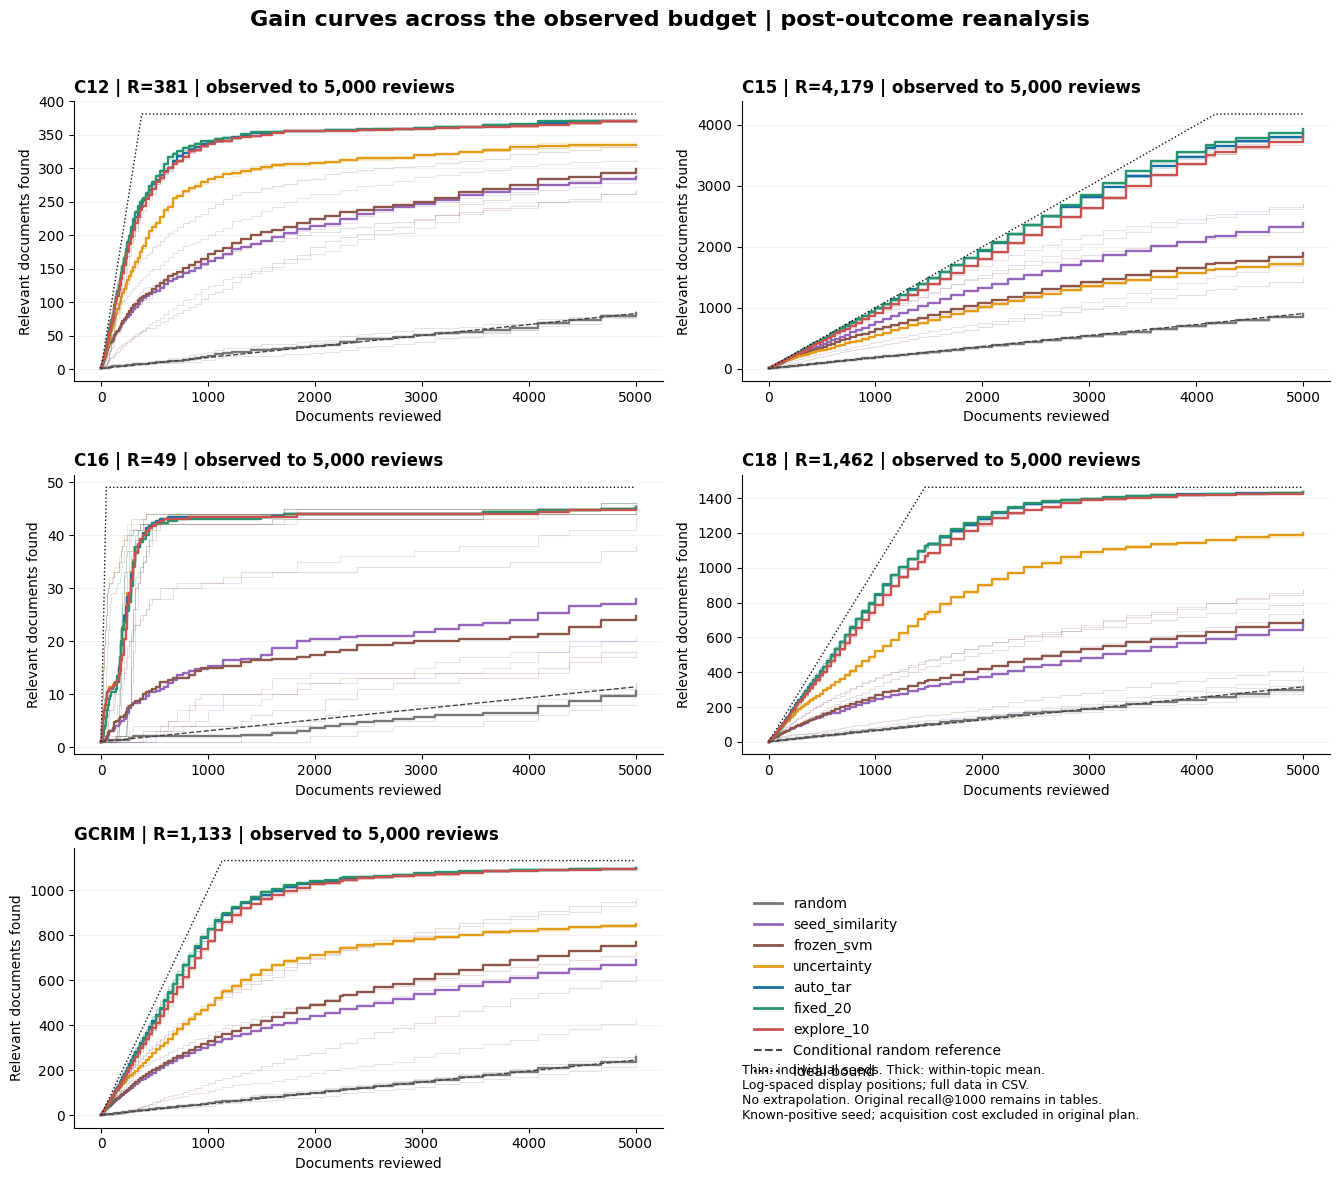

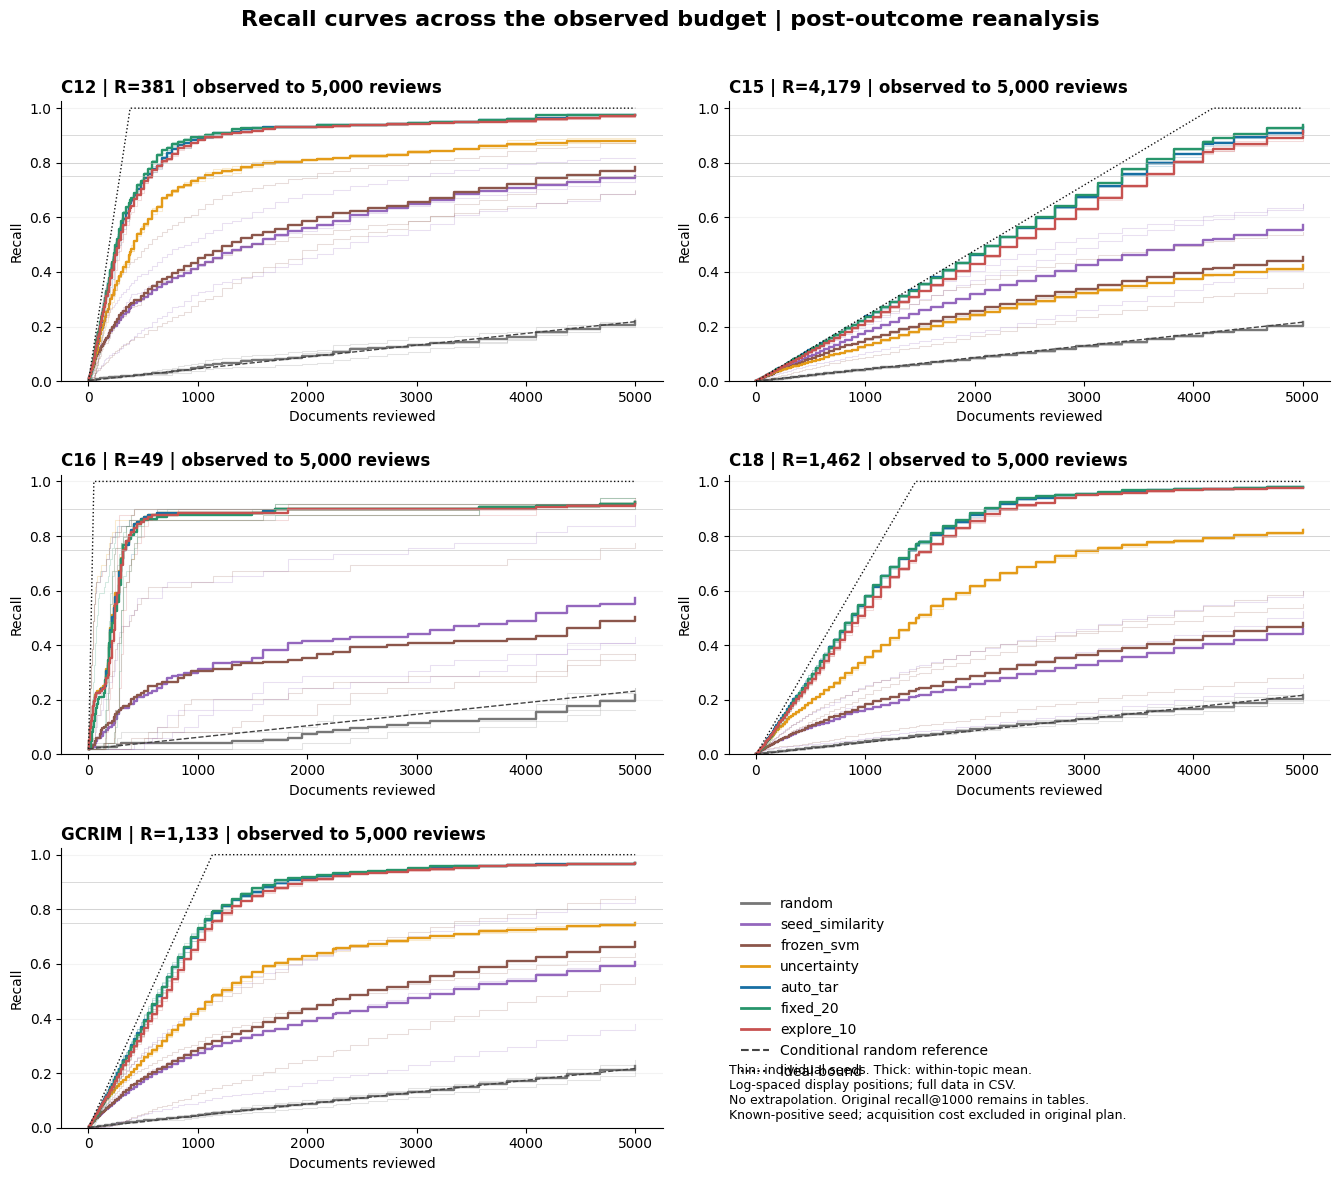

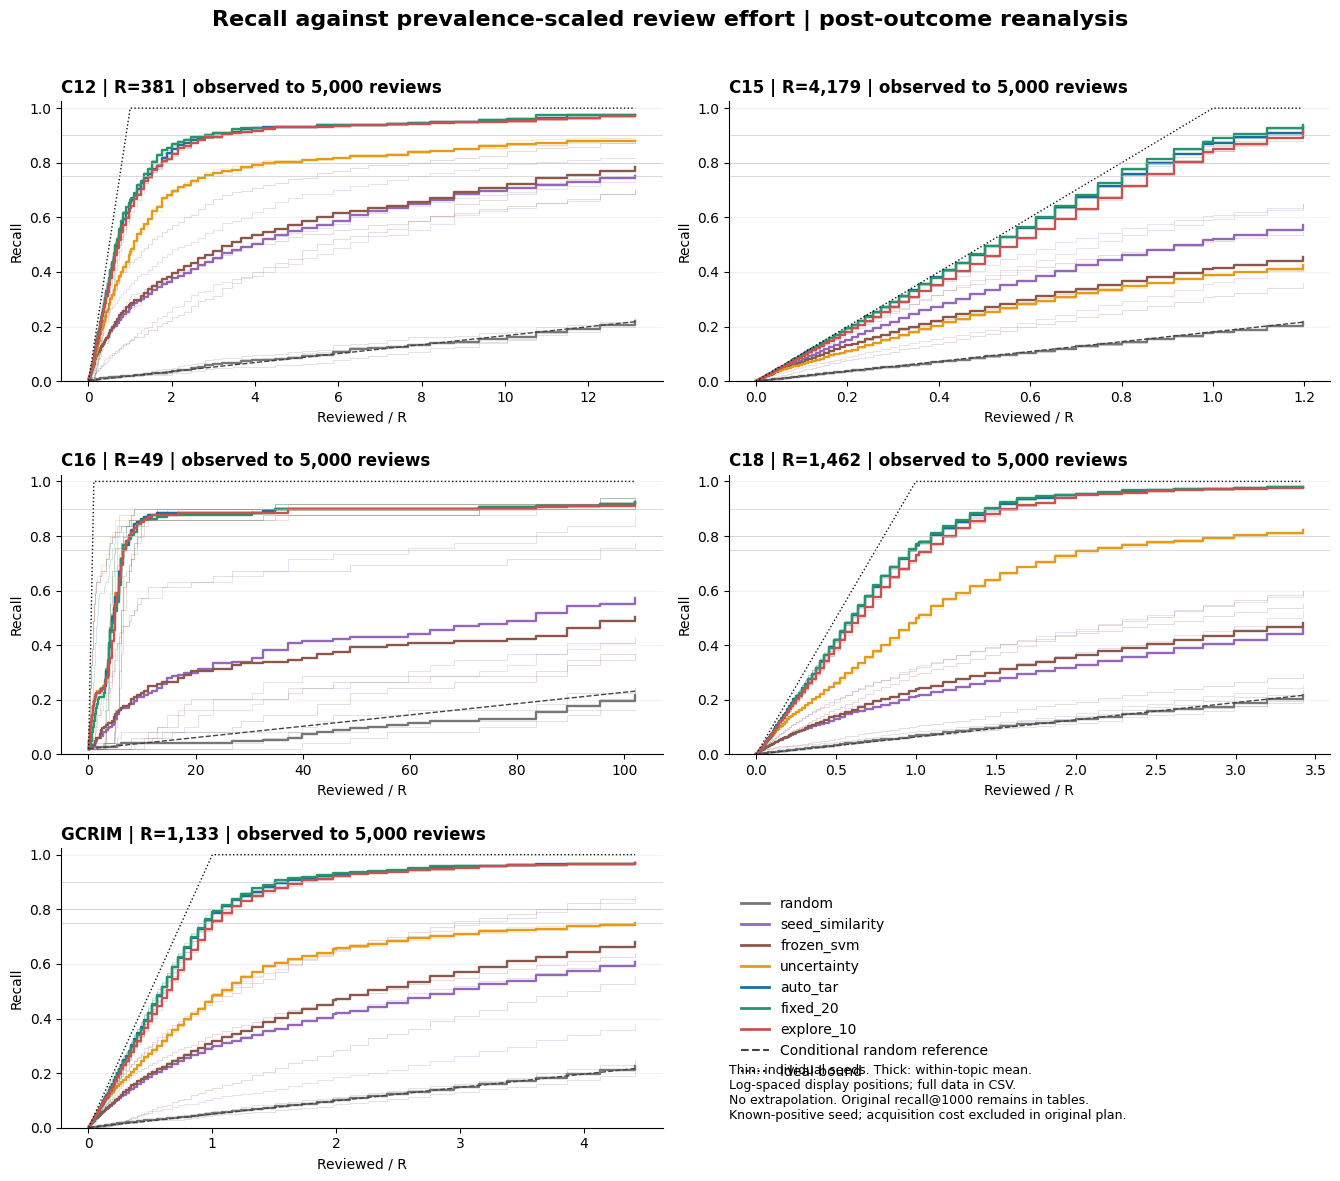

In [6]:
plt.rcParams.update({"font.family":"DejaVu Sans", "font.size":10,
                     "axes.spines.top":False, "axes.spines.right":False,
                     "savefig.facecolor":"white", "svg.hashsalt":"autotar-phase1"})
colors = dict(zip(methods, ["#777777","#9467bd","#8c564b","#e49b18","#176fa3","#27956b","#c75250"]))
figure_paths = []

def save_figure(fig, stem, caption):
    for extension, metadata in (
        ("png", {}), ("svg", {"Date":None}),
        ("pdf", {"CreationDate":None,"ModDate":None})):
        with atomic_file(FIG/f"{stem}.{extension}") as handle:
            fig.savefig(handle, format=extension, dpi=100, bbox_inches="tight", metadata=metadata)
    figure_paths.append(FIG/f"{stem}.png")
    raw = base64.b64encode((FIG/f"{stem}.png").read_bytes()).decode()
    sections.append(f"<section><h2>{html.escape(caption)}</h2><img alt='{html.escape(caption)}' src='data:image/png;base64,{raw}'></section>")
    display(Image(filename=str(FIG/f"{stem}.png")))
    plt.close(fig)

def draw_trajectories(mode):
    fig, axes = plt.subplots(3, 2, figsize=(13.5,12), squeeze=False)
    for ax, q in zip(axes.flat, topics_order):
        topic_curves = curves[curves.topic.eq(q)]
        r = int(population.loc[population.topic.eq(q),"R"].iloc[0])
        # Display-only sampling: all 525000 observed gain positions remain in CSV.
        budget = int(topic_curves.k.max())
        positions = np.unique(np.r_[np.rint(np.geomspace(1,budget,128)).astype(int),
                                    [1,1000,budget], [r] if r <= budget else [],
                                    [2*r] if 2*r <= budget else []])
        topic_curves = topic_curves[topic_curves.k.isin(positions)]
        for method in methods:
            data = topic_curves[topic_curves.policy.eq(method)]
            for _, run in data.groupby("seed"):
                x = run.normalized_effort if mode=="normalized" else run.k
                y = run.gain if mode=="gain" else run.recall
                ax.step(x,y,where="post",color=colors[method],alpha=.20,linewidth=.75)
            # Same per-topic budget verified; never average curves over differing coverage.
            average = data.groupby("k",sort=True).agg(gain=("gain","mean"),recall=("recall","mean"))
            x = average.index.to_numpy()/r if mode=="normalized" else average.index.to_numpy()
            y = average.gain if mode=="gain" else average.recall
            ax.step(x,y,where="post",color=colors[method],linewidth=1.7,label=method)
        ref = topic_curves[topic_curves.policy.eq(methods[0]) & topic_curves.seed.eq(original_plan["seeds"][0])]
        x = ref.normalized_effort if mode=="normalized" else ref.k
        scale = r if mode=="gain" else 1
        ax.plot(x,scale*ref.random_reference,color="#444444",linestyle="--",linewidth=1)
        ax.plot(x,scale*ref.ideal_bound,color="#111111",linestyle=":",linewidth=1)
        if mode!="gain":
            for target in (.75,.80,.90):
                ax.axhline(target,color="#b5b5b5",linewidth=.5,alpha=.7)
            ax.set_ylim(0,1.025)
        ax.set_title(f"{q} | R={r:,} | observed to {int(ref.k.max()):,} reviews",loc="left",fontweight="bold")
        ax.set_xlabel("Reviewed / R" if mode=="normalized" else "Documents reviewed")
        ax.set_ylabel("Relevant documents found" if mode=="gain" else "Recall")
        ax.grid(axis="y",alpha=.15)
    axes.flat[-1].axis("off")
    handles = [Line2D([0],[0],color=colors[m],lw=2,label=m) for m in methods]
    handles += [Line2D([0],[0],color="#444444",ls="--",label="Conditional random reference"),
                Line2D([0],[0],color="#111111",ls=":",label="Ideal bound")]
    axes.flat[-1].legend(handles=handles,loc="center left",frameon=False)
    axes.flat[-1].text(0,.02,"Thin: individual seeds. Thick: within-topic mean.\nLog-spaced display positions; full data in CSV.\nNo extrapolation. Original recall@1000 remains in tables.\nKnown-positive seed; acquisition cost excluded in original plan.",
                      transform=axes.flat[-1].transAxes,fontsize=9,va="bottom")
    title = {"gain":"Gain curves across the observed budget", "recall":"Recall curves across the observed budget",
             "normalized":"Recall against prevalence-scaled review effort"}[mode]
    fig.suptitle(title+" | post-outcome reanalysis",fontsize=16,fontweight="bold")
    fig.tight_layout(rect=(0,0,1,.965),h_pad=2)
    save_figure(fig,f"curves_{mode}",title)

for mode in ("gain","recall","normalized"):
    draw_trajectories(mode)

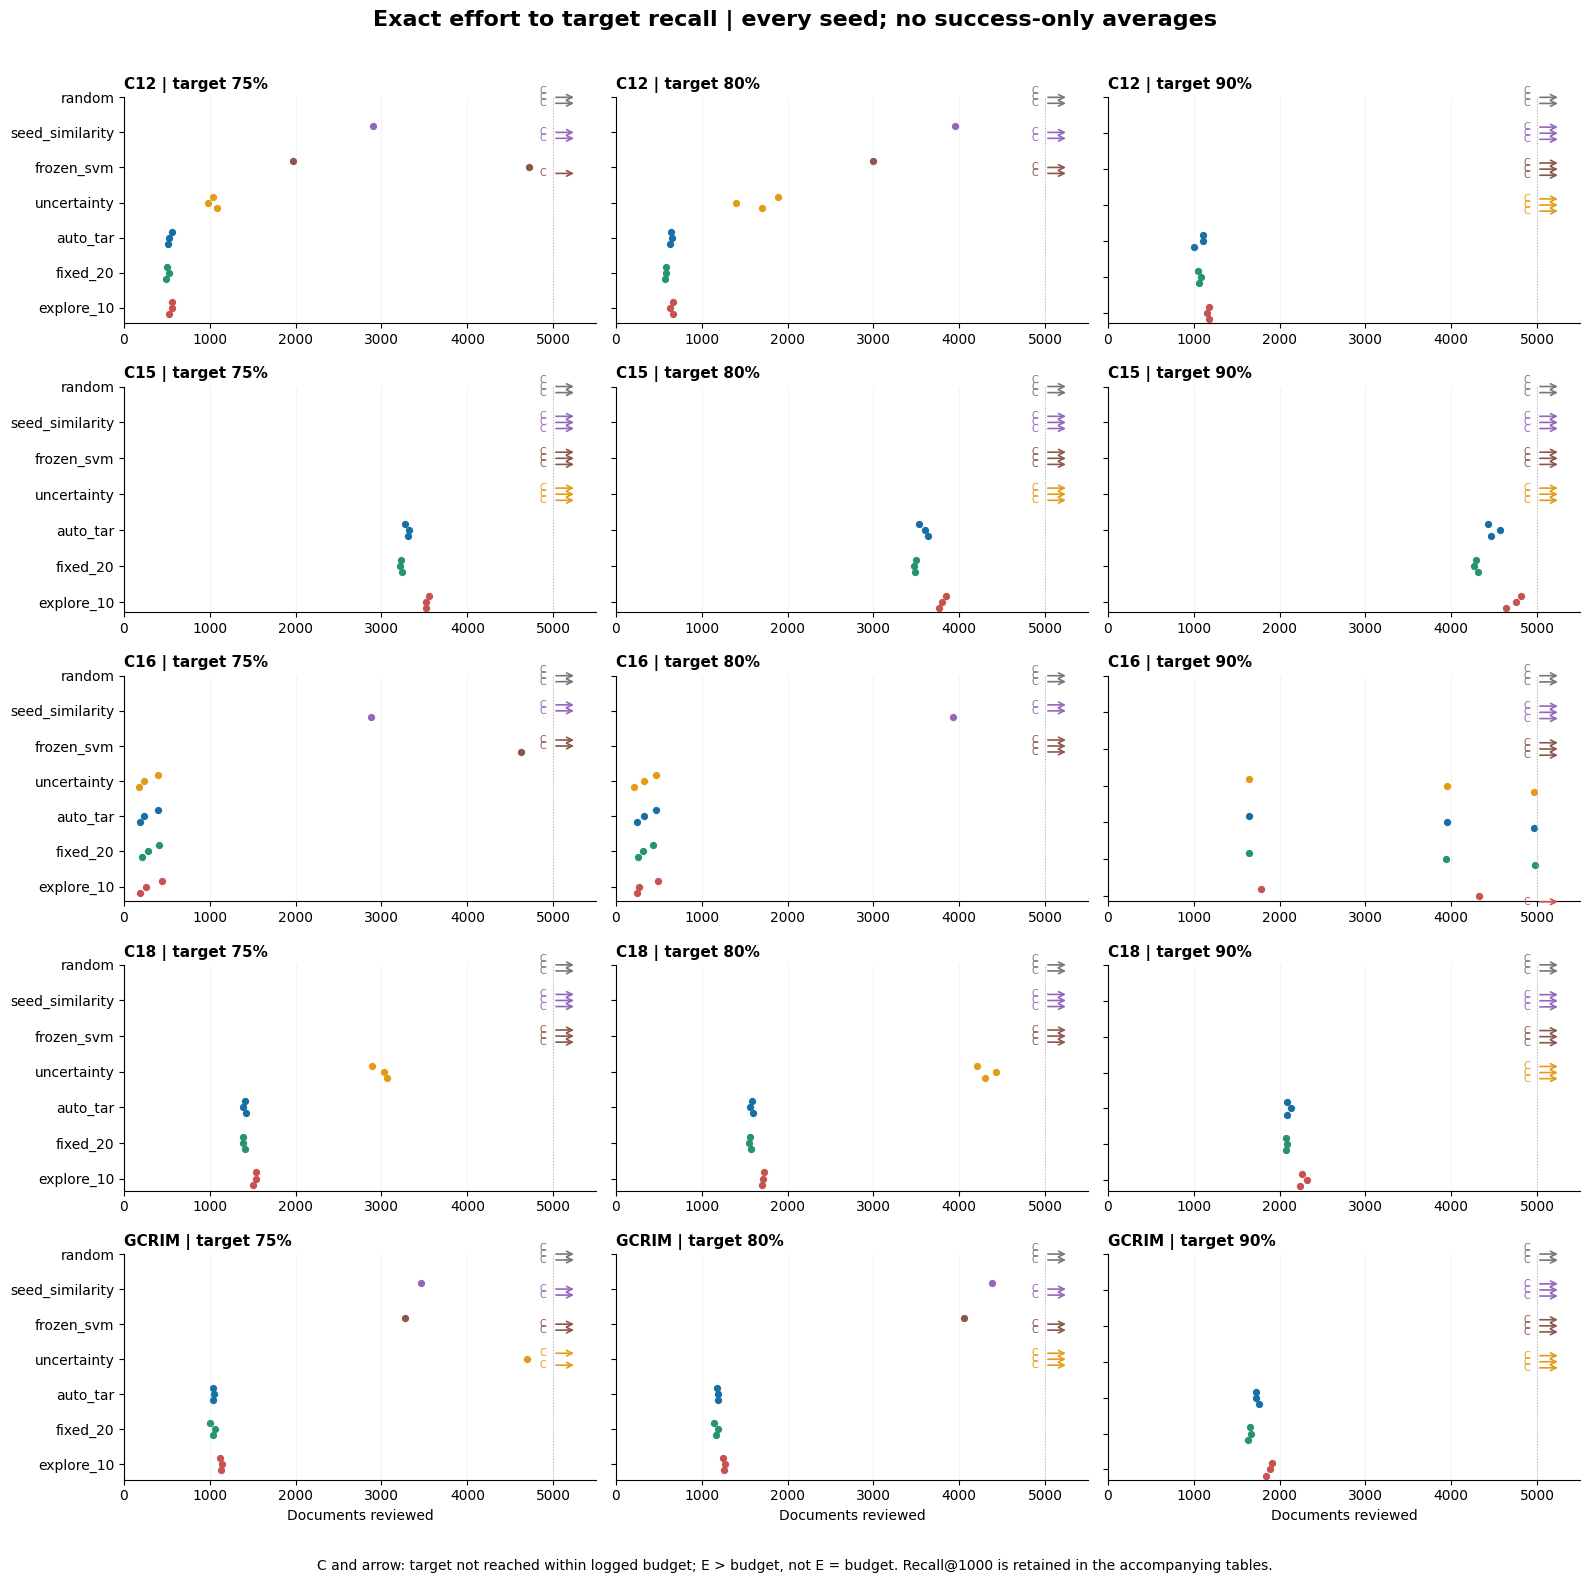

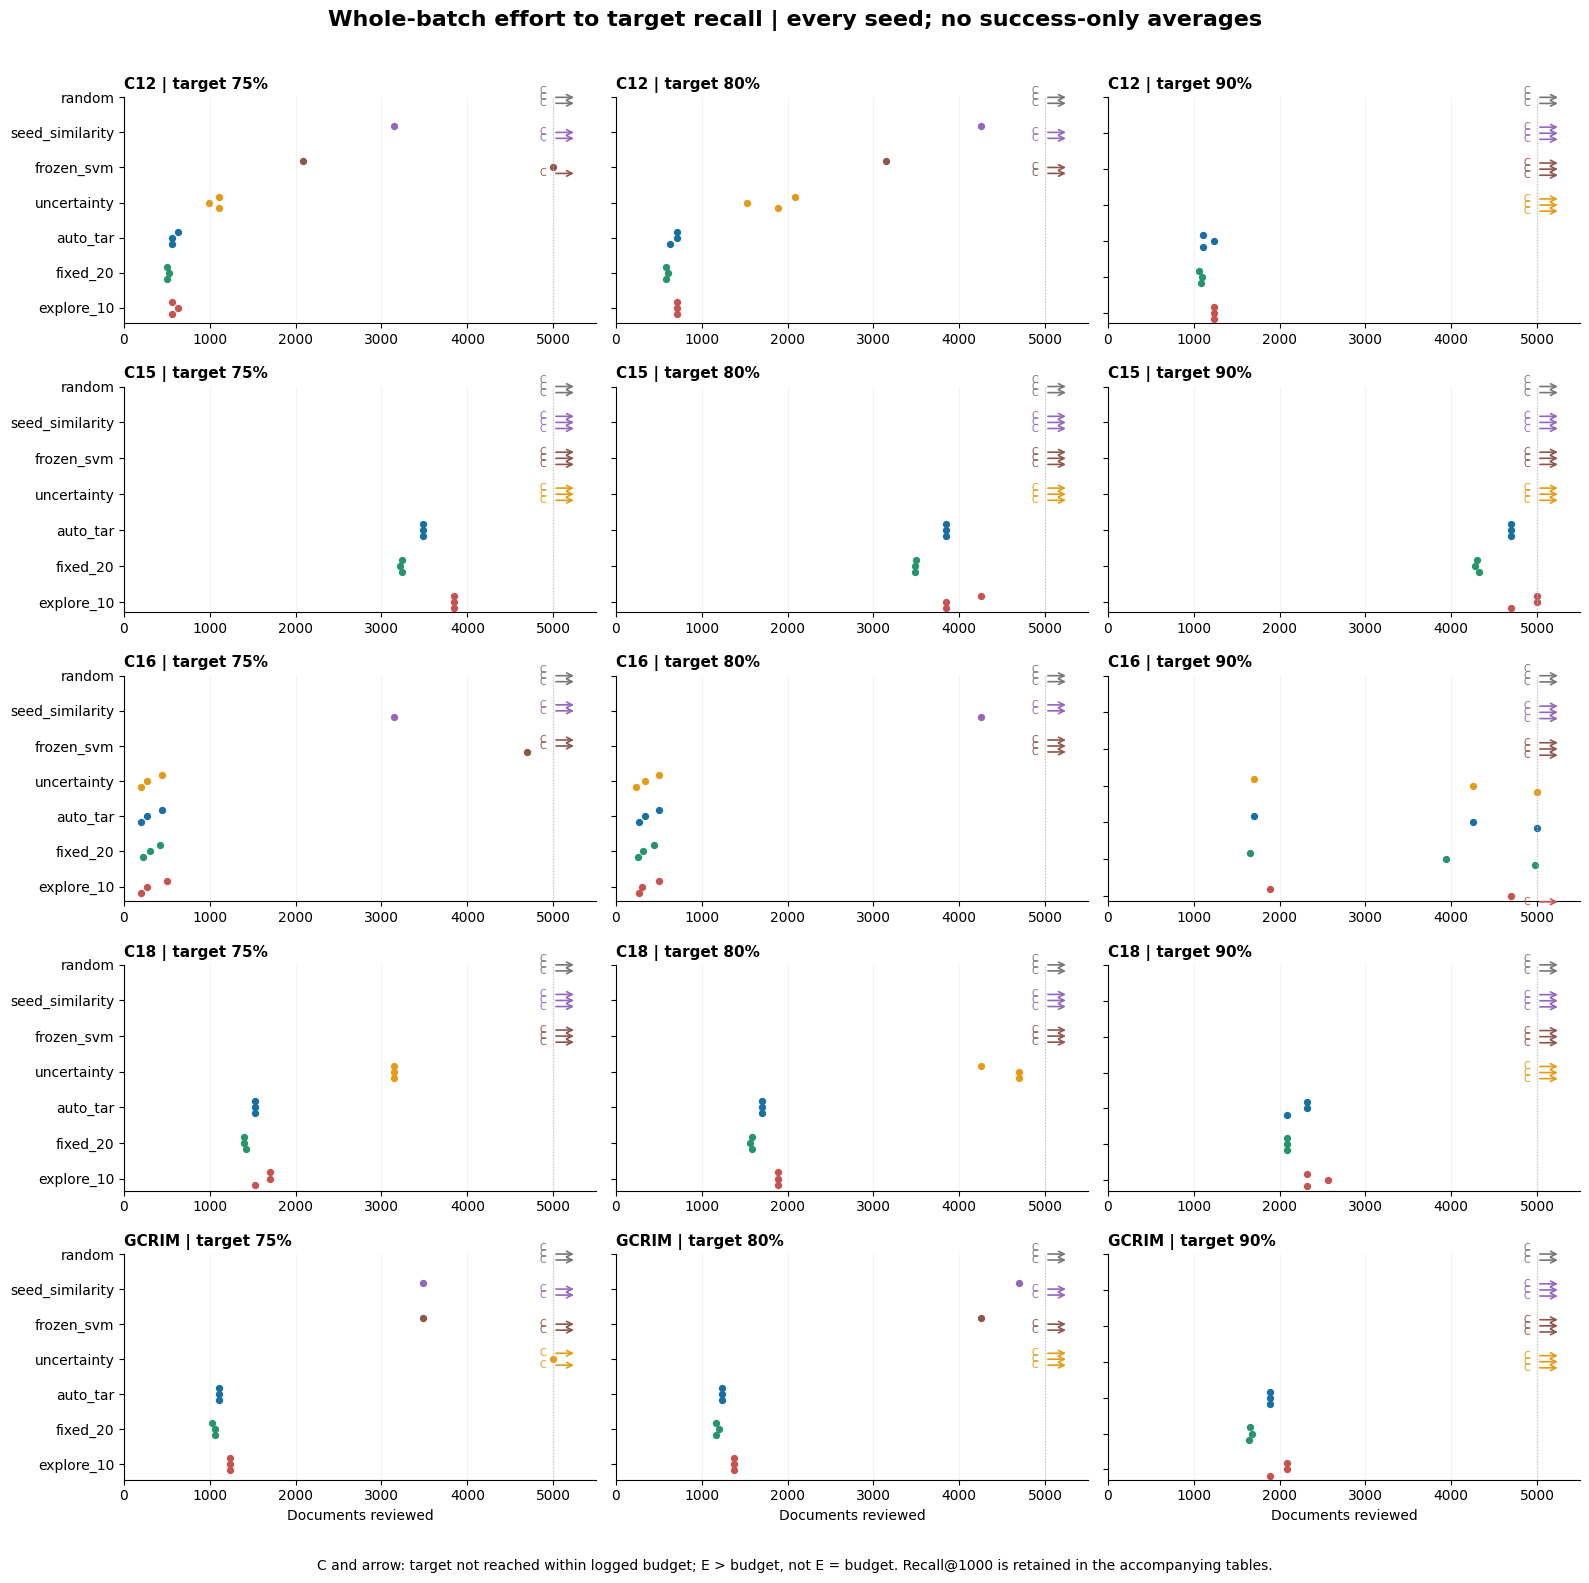

In [7]:
for stem in ("effort","batch_effort"):
    fig, axes = plt.subplots(5,3,figsize=(16,16))
    for qi,q in enumerate(topics_order):
        for ti,target in enumerate((75,80,90)):
            ax = axes[qi,ti]
            chosen = metrics[(metrics.topic==q) & (metrics.metric==f"{stem}_at_{target}")]
            for mi,method in enumerate(methods):
                selected = chosen[chosen.policy==method].sort_values("seed")
                offsets = np.linspace(-.17,.17,len(selected))
                for offset,row in zip(offsets,selected.itertuples()):
                    y = mi+offset
                    if row.status==OBSERVED:
                        ax.scatter(row.value,y,color=colors[method],s=18)
                    else:
                        # Arrow originates at a lower bound; it is not an observed effort.
                        ax.annotate("",xy=(row.reviewed*1.055,y),xytext=(row.reviewed,y),
                                    arrowprops={"arrowstyle":"->","color":colors[method],"lw":1.2})
                        ax.text(row.reviewed*.985,y,"C",ha="right",va="center",fontsize=7,color=colors[method])
            budget = int(chosen.reviewed.max())
            ax.axvline(budget,color="#bbbbbb",ls=":",lw=.8)
            ax.set_xlim(0,budget*1.10)
            ax.set_yticks(range(len(methods)),methods if ti==0 else [])
            ax.invert_yaxis()
            ax.set_title(f"{q} | target {target}%",loc="left",fontsize=11,fontweight="bold")
            ax.grid(axis="x",alpha=.15)
            if qi==4: ax.set_xlabel("Documents reviewed")
    title = "Exact effort to target recall" if stem=="effort" else "Whole-batch effort to target recall"
    fig.suptitle(title+" | every seed; no success-only averages",fontsize=16,fontweight="bold")
    fig.text(.5,.005,"C and arrow: target not reached within logged budget; E > budget, not E = budget. Recall@1000 is retained in the accompanying tables.",
             ha="center",fontsize=10)
    fig.tight_layout(rect=(0,.025,1,.97),h_pad=1.4)
    save_figure(fig,f"targets_{stem}",title)

## Scope and verification

These checks establish agreement with archived records and immutability, not independent ground truth. No hand-computed expected fixture has been created. The original loop was not rerun. The original seed-only frozen policy name remains unchanged in historical data. Margins/probabilities, certification and cross-implementation replay are outside Phase 1.

Stop here for user review before Phase 2. New RNG streams, exploration truncation fixes, config wiring, renames and audit instrumentation remain unimplemented.

In [8]:
versions = {name:importlib.metadata.version(name) for name in
            ("numpy","pandas","scipy","matplotlib","nbformat","nbclient","ipykernel","Pillow","PyMuPDF")}
verification = {"status":"PASSED", "scope":"Archived-input consistency and Phase 1 execution only",
                "runs_validated":len(records), "audits_validated":len(audits),
                "protected_files_unchanged":check_protected(),
                "metric_rows":len(metrics), "topic_metric_rows":len(topic_values),
                "pairwise_contrasts":len(stats),
                "computed_full_topic_contrasts":int(stats.status.eq(OBSERVED).sum()),
                "censored_metric_rows":len(censor_inventory),
                "gain_curve_positions":len(curves),
                "original_primary_metric":original_plan["primary_metric"],
                "revised_primary_metric":plan["primary_metric"],
                "revision_after_outcomes":True, "external_ground_truth_verified":False,
                "phase_2_started":False, "versions":versions, "python":platform.python_version()}
(OUT/"verification.json").write_text(json.dumps(verification,indent=2)+"\n")
(OUT/"analysis_environment.json").write_text(json.dumps({"python":platform.python_version(),"packages":versions},indent=2)+"\n")
header = """<!doctype html><html lang="en"><meta charset="utf-8"><title>Phase 1 AutoTAR metric review</title>
<style>body{font-family:system-ui,sans-serif;max-width:1250px;margin:36px auto;padding:0 24px;color:#18252e;line-height:1.5}
h1{font-size:32px}h2{margin-top:32px;font-size:21px}.notice{background:#fff3d8;border-left:4px solid #bc7a00;padding:18px}
.table-wrap{overflow-x:auto}table{border-collapse:collapse;font-size:13px;width:100%}th,td{padding:9px;border-bottom:1px solid #dce2e6;text-align:left;vertical-align:top}th{background:#edf2f5}img{max-width:100%;height:auto}section{margin:30px 0}code{background:#edf2f5;padding:2px 5px}</style><body>
<h1>Phase 1: recall@R is fully observed across all 105 runs</h1><p>Recall@R has 0/105 censored runs and 0/21 censored policy pairs. Original recall@1000 is also fully observed. Deeper measures are limited by the 5,000-document budget.</p>
<div class="notice"><strong>Post-outcome exploratory reanalysis.</strong> The original primary metric was recall@1000. Recall@R was selected as a revised primary AFTER original outcomes had been observed. Both remain visible. No new experiments, external ground-truth validation, or stopping certification were performed.</div>
<p>Read-only inputs: results/runs.csv and results/audits/*.json. N and R are sourced exclusively from the CSV. The original plan already disclosed exclusion of seed discovery/search cost.</p>"""
footer = "<section><h2>Verification and phase gate</h2><pre>"+html.escape(json.dumps(verification,indent=2))+"</pre><p>Phase 1 awaits user review. Phases 2–5 remain unimplemented. Bootstrap intervals are unstable with five topics; nonsignificance does not establish equivalence.</p></section></body></html>"
(OUT/"results.html").write_text(header+"\n".join(sections)+footer)
with (OUT/"results_tables.md").open("w") as handle:
    handle.write("# Phase 1 results tables\n\nRecall@R: fully observed, 0/105 runs and 0/21 pairs censored. Original recall@1000 retained. POST-OUTCOME metric revision.\n\n")
    for title,frame in [("Original and revised metrics",primary_display), ("Censoring census",census)] + [
        (f"Target {t}%", summary_display(summary,["recall_at_1000"]+
          [f"{s}_at_{t}" for s in ("effort","batch_effort","depth_fraction","depth_per_positive")],methods))
        for t in (75,80,90)]:
        handle.write("## "+title+"\n\n")
        handle.write("| "+" | ".join(frame.columns)+" |\n")
        handle.write("| "+" | ".join("---" for _ in frame.columns)+" |\n")
        for values in frame.itertuples(index=False,name=None):
            handle.write("| "+" | ".join(str(v).replace("|",";") for v in values)+" |\n")
        handle.write("\n")
    handle.write("Complete per-topic, per-seed, scaled-cutoff and statistical tables are regenerated by the notebook and exported as CSV/HTML. No full effort mean is computed when any contributing seed/topic is censored.\n")
print(json.dumps(verification,indent=2))
print("Review report: results.html in the configured Phase 1 output directory")
print("STOP: Phase 1 review gate; do not begin Phase 2.")
def markdown_table(frame):
    lines = ["| " + " | ".join(frame.columns) + " |",
             "| " + " | ".join("---" for _ in frame.columns) + " |"]
    for values in frame.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(str(v).replace("|",";") for v in values) + " |")
    return "\n".join(lines)

core = summary_display(summary, ["recall_at_R","recall_at_1000"], methods)
material = stats[stats.interval_disagreement.eq("MATERIAL")]
report = """# IST Review Lab: Phase 1 results

Recall@R is fully observed: **0/105 runs and 0/21 policy comparisons censored**.
This is the reportable core across five topics, three seeds and seven policies.
The original declared recall@1000 remains fully observed and visible alongside it.
Recall@R became the revised primary AFTER outcomes were observed; this is exploratory reanalysis,
not advance prespecification or an exact replication of the paper's result tables.

## Fully observed measures

Topic means require all three seeds; the macro mean weights all five topics equally.

""" + markdown_table(core) + """

The exact sign-flip test on five seed-averaged topic differences is the primary inferential statement.
With at most five nonzero topic differences its smallest attainable two-sided p-value is 0.0625.
Neither nonsignificance nor close means establish equivalence.
Every contrast table reports both 95% percentile and BCa intervals and the raw five differences.
Agreement between the two intervals does not establish reliable coverage at this sample size.

""" + f"Material BCa/percentile disagreement occurs in {len(material)} of the {int(stats.status.eq(OBSERVED).sum())} fully observed metric/pair contrasts (metric aliases included). " + """
Material means different zero inclusion or a maximum endpoint shift of at least 25% of the percentile interval width.
This diagnostic was selected in the post-outcome amendment, before computing BCa.
Disagreement is evidence that interval inference is not trustworthy here.

## Censored measures: the 5,000-document budget

""" + markdown_table(census) + """

Recall@2R is unobserved for every C15 run; any four-topic recall mean must explicitly exclude C15.
The recall@4R family additionally censors C18, and at 4R+1000 also GCRIM.
Most target-effort policy comparisons are censored: 18/21 at 75% and 80%, 20/21 at 90%.
Every topic contributes. The 5,000-document budget is too short for these complete five-topic
comparisons. No success-only effort mean or complete-case inference replaces them.

The five full gain trajectories per topic/policy/seed remain available at every observed review
position in gain_curves.csv.gz. Figures use log-spaced display positions for compact rendering;
this changes presentation only. Seed acquisition cost was excluded in the original plan.

## Scope and deferred work

No learning experiment was rerun. No load_collection() or experiment.py was invoked.
Phase 2 will split RNG streams; no redundant pool/tail option will be implemented.
After Phase 3 instrumentation passes exact replay, a new-generation run must cover all five topics
to budget=N=23,149 with the new streams. Do not perform that run in Phase 1 or Phase 2.
This study concerns fixed-label document retrieval, not sales conversion or stopping certification.
The whole Phase 1 gate status is recorded separately in notebook_execution.json; this table report
alone does not certify artifact completeness or repeatability.
"""
with atomic_file(OUT/"RESULTS.md", "w") as handle:
    handle.write(report)


{
  "status": "PASSED",
  "scope": "Archived-input consistency and Phase 1 execution only",
  "runs_validated": 105,
  "audits_validated": 105,
  "protected_files_unchanged": 129,
  "metric_rows": 2520,
  "topic_metric_rows": 840,
  "pairwise_contrasts": 504,
  "computed_full_topic_contrasts": 112,
  "censored_metric_rows": 840,
  "gain_curve_positions": 525000,
  "original_primary_metric": "recall_at_1000",
  "revised_primary_metric": "recall_at_R",
  "revision_after_outcomes": true,
  "external_ground_truth_verified": false,
  "phase_2_started": false,
  "versions": {
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "scipy": "1.17.0",
    "matplotlib": "3.10.8",
    "nbformat": "5.10.4",
    "nbclient": "0.10.2",
    "ipykernel": "6.30.1",
    "Pillow": "12.3.0",
    "PyMuPDF": "1.26.6"
  },
  "python": "3.12.13"
}
Review report: results.html in the configured Phase 1 output directory
STOP: Phase 1 review gate; do not begin Phase 2.
